# [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/pdf/1412.6550)

## Introduction

Turning pre-trained models into task-specific models via fine-tuning is expensive, since we train and store all the weights for each task.

There was two main methods of addressing the above issue prior to LoRA:

1] **[Adapters](https://arxiv.org/pdf/1902.00751)**: Insert small bottleneck modules within each layer of a frozen pretrained model, which project hidden states into a lower-dimensional space and then project them back to the original hidden size. This enables task-specific adaptation with a minimal number of additional parameters.

2a] **[Prefix-tuning](https://arxiv.org/abs/2101.00190)**: Learn continuous task-specific vectors that are injected as additional key/value pairs in the attention mechanism at each layer, while keeping the pretrained model frozen. This enables input sequence to attend to learned task-specific memory.

2b] **[Prompt-tuning](https://arxiv.org/pdf/2104.08691)**: Learn task-specific continuous embeddings that are prepended to the input sequence as "soft tokens", with all pre-trained weights frozen.

**Gap:** Adapters introduce inference latency by extending model depth, while prompt-tuning reduces the model's usable sequence length.

**Improvement:** LoRA enables tailoring pre-trained models for specific tasks without additional inference latency and without eating into the mode's usable sequence length.

## Approach

LoRA training learns the change in weights ($\Delta{W}$) needed for a pre-trained model to adapt to a dataset without actually training the model's weights.

But directly learning $\Delta{W}$ requires learning same number of parameters as learning $W$. To train for $\Delta{W}$ more efficiently, they approximate $\Delta{W}$ using a low-rank factorization:

$$
\Delta{W} = AB
$$

Let $\Delta{W}$ be dimensions $n \ * \ m$. Then, $A$ and $B$ are dimensions $n \ * \ k$ and $k \ * \ m$, respectively. This constrains $\Delta{W}$ to have rank at most $k$.

If $\#params (\Delta{W}) = 100 * 50 = 5,000$, then a rank of at most $k = 3$ would reduce the training parameters from $5000$ to $\#params (A) + \#params (B) = 100 * 3 + 3 * 50 = 450$.

So for pre-trained weights, $W_0$, LoRA training updates standard training like so: 

$$h = W_0x \rightarrow h = (W_0 + \Delta{W})x = (W_0 + AB)x = W_0x + ABx$$

## Result

- Compared to GPT-3 175B full fine-tuning, LoRA can reduce trainable parameters by 10,000 times and the GPU memory requirement by 3 times.
- Adapter-based methods contain 20% more latency than LoRA on single instance inference. LoRA adds no latency compared to fine-tuning since $AB$ can be absorbed into the weights for inference.
- Showed that LoRA performs on-par or better than fine-tuning and adapters in model quality.

## Application

We compare five fine-tuning strategies on the same model (`bert-base-uncased`) and the same task (binary toxicity classification on `data/toxicity_en.csv`) so efficiency and performance numbers are directly comparable:

1. **Full fine-tuning** — every weight updated (baseline)
2. **Adapters** — bottleneck modules inserted per-layer, rest frozen
3. **Prefix-tuning** — learned key/value prefixes injected into attention, rest frozen
4. **Prompt-tuning** — learned soft-token embeddings prepended to the input, rest frozen
5. **LoRA** — low-rank $\Delta W = BA$ update to $W_q$/$W_v$, rest frozen

For each method we measure **efficiency** (# trainable params, peak GPU memory, time/training step) and **performance** (accuracy/F1 on a held-out test split).

In [1]:
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "bert-base-uncased"
print("Using device:", device)

Using device: cuda


In [2]:
df = pd.read_csv("data/toxicity_en.csv")
df["is_toxic"] = (df["is_toxic"] == "Toxic").astype(int)

train_df, test_df = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df["is_toxic"]
)
print(f"train: {len(train_df)}, test: {len(test_df)}")
df["is_toxic"].value_counts()

train: 850, test: 150


is_toxic
1    501
0    499
Name: count, dtype: int64

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ToxicDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["text"].values
        self.labels = df["is_toxic"].values
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float),
        }


BATCH_SIZE = 16
train_dataset = ToxicDataset(train_df, tokenizer)
test_dataset = ToxicDataset(test_df, tokenizer)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Shared training/evaluation harness

Every method below plugs into the same harness: it supplies a (possibly wrapped/frozen) `backbone`, a fresh `classifier` head, the list of `trainable_params` for the optimizer, and a `forward_fn` that returns the `[CLS]` embedding (some methods change the effective sequence, so how `[CLS]` is obtained differs slightly). The harness measures trainable parameter count, peak GPU memory, average time/training-step, and test accuracy/F1.

In [4]:
class ClassifierHead(nn.Module):
    def __init__(self, hidden_size=768, output_size=1):
        super().__init__()
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        return self.linear(x)


def count_trainable_params(*modules):
    return sum(p.numel() for m in modules for p in m.parameters() if p.requires_grad)


results = []


def train_and_evaluate(name, backbone, classifier, trainable_params, forward_fn, epochs=3, lr=2e-5):
    """Trains `backbone` + `classifier`, measuring efficiency and performance.

    `forward_fn(backbone, input_ids, attention_mask) -> cls_embedding (B, H)` abstracts
    away how each PEFT method feeds the model (some change inputs_embeds / sequence length).
    """
    backbone.to(device)
    classifier.to(device)
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

    step_times = []
    backbone.train()
    classifier.train()
    for epoch in range(epochs):
        loop = tqdm(train_dataloader, desc=f"[{name}] epoch {epoch + 1}/{epochs}", leave=False)
        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            if device == "cuda":
                torch.cuda.synchronize()
            t0 = time.time()

            optimizer.zero_grad()
            cls_emb = forward_fn(backbone, input_ids, attention_mask)
            logits = classifier(cls_emb).squeeze(-1)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            if device == "cuda":
                torch.cuda.synchronize()
            step_times.append(time.time() - t0)
            loop.set_postfix(loss=loss.item())

    peak_mem_mb = torch.cuda.max_memory_allocated() / 1024**2 if device == "cuda" else float("nan")
    # skip the first few steps (cudnn/autotune warmup) when averaging step time
    warm_steps = step_times[5:] if len(step_times) > 5 else step_times
    avg_step_ms = 1000 * float(np.mean(warm_steps))

    backbone.eval()
    classifier.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"[{name}] testing", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            cls_emb = forward_fn(backbone, input_ids, attention_mask)
            logits = classifier(cls_emb).squeeze(-1)
            preds = (torch.sigmoid(logits) > 0.5).long().cpu()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.long().tolist())

    result = {
        "method": name,
        "trainable_params": count_trainable_params(backbone, classifier),
        "peak_mem_mb": peak_mem_mb,
        "avg_step_ms": avg_step_ms,
        "accuracy": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds),
    }
    results.append(result)
    return result

### 1. Full Fine-Tuning (baseline)

Every parameter of BERT, plus the classifier head, is updated. This is the most expressive option but also the most expensive in memory, compute, and per-task storage — it's the baseline the PEFT methods below are compared against.

In [5]:
def build_full_finetune():
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = True
    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

    trainable_params = list(backbone.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_full_finetune()
train_and_evaluate("Full Fine-Tuning", backbone, classifier, trainable_params, forward_fn, epochs=3, lr=2e-5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Full Fine-Tuning] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Full Fine-Tuning] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Full Fine-Tuning',
 'trainable_params': 109483009,
 'peak_mem_mb': 2536.72412109375,
 'avg_step_ms': 118.24399954194476,
 'accuracy': 0.92,
 'f1': 0.9178082191780822}

### 2. Adapters

A small bottleneck module (down-project &rarr; nonlinearity &rarr; up-project, added back via a residual connection) is inserted after every transformer layer's output. Only the adapters and the classifier head are trained; the rest of BERT stays frozen. The up-projection is zero-initialized so each adapter starts as an identity function, keeping early training stable.

In [6]:
class Adapter(nn.Module):
    def __init__(self, hidden_size=768, bottleneck=64):
        super().__init__()
        self.down = nn.Linear(hidden_size, bottleneck)
        self.act = nn.GELU()
        self.up = nn.Linear(bottleneck, hidden_size)
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))


def build_adapters(bottleneck=64):
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = False

    adapters = nn.ModuleList([Adapter(backbone.config.hidden_size, bottleneck) for _ in backbone.encoder.layer])
    for layer, adapter in zip(backbone.encoder.layer, adapters):
        def make_hook(adapter):
            def hook(module, inputs, output):
                return adapter(output)
            return hook
        layer.register_forward_hook(make_hook(adapter))
    backbone.injected_adapters = adapters  # register as a submodule -> trainable & moves with .to(device)

    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

    trainable_params = list(adapters.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_adapters()
train_and_evaluate("Adapters", backbone, classifier, trainable_params, forward_fn, epochs=3, lr=1e-3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Adapters] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Adapters] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Adapters] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Adapters] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Adapters',
 'trainable_params': 1190401,
 'peak_mem_mb': 1306.7705078125,
 'avg_step_ms': 72.0450969258691,
 'accuracy': 0.94,
 'f1': 0.9403973509933775}

### 3. Prefix-Tuning

Each self-attention layer gets its own trainable "virtual" key/value vectors (a prefix) that are prepended to the real keys/values before the attention softmax, so every token can attend to them. Unlike prompt-tuning, the prefix never joins the residual stream or the output sequence — it only steers attention — so the `[CLS]` position is unchanged. All original BERT weights stay frozen; only the per-layer prefixes and the classifier head are trained.

**Implementation note:** this `transformers` version routes attention through an internal `Cache`/masking API that changes across versions. To keep this self-contained and version-robust, we replace each layer's self-attention `forward` with a small scaled-dot-product implementation that concatenates the learned prefix K/V and rebuilds the padding mask directly from the batch's attention mask (stashed on the module beforehand), rather than depending on internal mask utilities.

In [7]:
class PrefixEncoder(nn.Module):
    def __init__(self, num_heads, head_dim, prefix_len=10):
        super().__init__()
        self.prefix_len = prefix_len
        self.prefix_k = nn.Parameter(torch.randn(num_heads, prefix_len, head_dim) * 0.02)
        self.prefix_v = nn.Parameter(torch.randn(num_heads, prefix_len, head_dim) * 0.02)


def patch_self_attention_with_prefix(self_attn, prefix_encoder):
    """Replaces `self_attn.forward` so learned prefix K/V are attended to alongside real tokens."""

    def forward(hidden_states, attention_mask=None, past_key_values=None, **kwargs):
        B, S, _ = hidden_states.shape
        H, D = self_attn.num_attention_heads, self_attn.attention_head_size
        shape = (B, S, H, D)

        q = self_attn.query(hidden_states).view(*shape).transpose(1, 2)
        k = self_attn.key(hidden_states).view(*shape).transpose(1, 2)
        v = self_attn.value(hidden_states).view(*shape).transpose(1, 2)

        pk = prefix_encoder.prefix_k.unsqueeze(0).expand(B, -1, -1, -1).to(k.dtype)
        pv = prefix_encoder.prefix_v.unsqueeze(0).expand(B, -1, -1, -1).to(v.dtype)
        k = torch.cat([pk, k], dim=2)
        v = torch.cat([pv, v], dim=2)

        pad_mask = self_attn._padding_mask.to(q.dtype)  # (B, S), stashed by forward_fn below
        prefix_ones = torch.ones(B, prefix_encoder.prefix_len, device=pad_mask.device, dtype=pad_mask.dtype)
        full_mask = torch.cat([prefix_ones, pad_mask], dim=1)
        additive_mask = (1.0 - full_mask)[:, None, None, :] * torch.finfo(q.dtype).min

        attn_scores = torch.matmul(q, k.transpose(-1, -2)) * self_attn.scaling + additive_mask
        attn_probs = F.softmax(attn_scores, dim=-1)
        context = torch.matmul(attn_probs, v).transpose(1, 2).reshape(B, S, -1)
        return (context, attn_probs)

    self_attn.forward = forward


def build_prefix_tuning(prefix_len=10):
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = False

    num_heads = backbone.config.num_attention_heads
    head_dim = backbone.config.hidden_size // num_heads
    prefix_encoders = nn.ModuleList(
        [PrefixEncoder(num_heads, head_dim, prefix_len) for _ in backbone.encoder.layer]
    )
    for layer, enc in zip(backbone.encoder.layer, prefix_encoders):
        patch_self_attention_with_prefix(layer.attention.self, enc)
    backbone.injected_prefixes = prefix_encoders

    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        for layer in backbone.encoder.layer:
            layer.attention.self._padding_mask = attention_mask
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]  # CLS position unchanged: prefix never joins the sequence

    trainable_params = list(prefix_encoders.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_prefix_tuning()
train_and_evaluate("Prefix-Tuning", backbone, classifier, trainable_params, forward_fn, epochs=3, lr=1e-3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Prefix-Tuning] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prefix-Tuning] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prefix-Tuning] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prefix-Tuning] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Prefix-Tuning',
 'trainable_params': 185089,
 'peak_mem_mb': 1356.5380859375,
 'avg_step_ms': 75.0692057761417,
 'accuracy': 0.8666666666666667,
 'f1': 0.8571428571428571}

### 4. Prompt-Tuning

A small number of trainable "soft token" embeddings are prepended directly to the input's word embeddings (only at the input, not at every layer), then flow through the frozen encoder like any other token. The attention mask is extended so the soft tokens are always attended to. Only the soft-prompt embeddings and the classifier head are trained. Because the soft tokens occupy real sequence positions, `[CLS]` shifts to index `n_tokens`.

In [8]:
class SoftPrompt(nn.Module):
    def __init__(self, n_tokens, hidden_size):
        super().__init__()
        self.embedding = nn.Parameter(torch.randn(n_tokens, hidden_size) * 0.5)

    def forward(self, batch_size):
        return self.embedding.unsqueeze(0).expand(batch_size, -1, -1)


def build_prompt_tuning(n_tokens=10):
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = False

    soft_prompt = SoftPrompt(n_tokens, backbone.config.hidden_size)
    backbone.soft_prompt = soft_prompt
    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        B = input_ids.shape[0]
        input_embeds = backbone.embeddings.word_embeddings(input_ids)
        prompt_embeds = backbone.soft_prompt(B).to(input_embeds.dtype)
        full_embeds = torch.cat([prompt_embeds, input_embeds], dim=1)

        prompt_mask = torch.ones(B, n_tokens, device=attention_mask.device, dtype=attention_mask.dtype)
        full_mask = torch.cat([prompt_mask, attention_mask], dim=1)

        out = backbone(inputs_embeds=full_embeds, attention_mask=full_mask)
        return out.last_hidden_state[:, n_tokens, :]  # CLS shifted past the soft prompt tokens

    trainable_params = list(soft_prompt.parameters()) + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_prompt_tuning()
train_and_evaluate("Prompt-Tuning", backbone, classifier, trainable_params, forward_fn, epochs=3, lr=1e-3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Prompt-Tuning] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prompt-Tuning] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prompt-Tuning] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[Prompt-Tuning] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'Prompt-Tuning',
 'trainable_params': 8449,
 'peak_mem_mb': 1462.203125,
 'avg_step_ms': 84.12234342781602,
 'accuracy': 0.8066666666666666,
 'f1': 0.7819548872180451}

### 5. LoRA

Following the paper, LoRA is applied only to the query and value projection matrices of every self-attention layer. Each frozen `nn.Linear` is wrapped with a low-rank update $\Delta W = BA$ (rank $r=8$), so the effective weight becomes $W_0 + \frac{\alpha}{r}BA$. `B` is zero-initialized so training starts exactly at the pretrained model. Only `A`, `B`, and the classifier head are trained — no other frozen weight is ever touched, and (per the paper) $BA$ could be merged into $W_0$ at inference time for zero extra latency.

In [9]:
class LoRALinear(nn.Module):
    def __init__(self, base_linear, r=8, alpha=16):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False

        in_features, out_features = base_linear.in_features, base_linear.out_features
        self.lora_A = nn.Parameter(torch.randn(r, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, r))
        self.scaling = alpha / r

    def forward(self, x):
        return self.base(x) + (x @ self.lora_A.T @ self.lora_B.T) * self.scaling


def build_lora(r=8, alpha=16):
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    for p in backbone.parameters():
        p.requires_grad = False

    for layer in backbone.encoder.layer:
        sa = layer.attention.self
        sa.query = LoRALinear(sa.query, r, alpha)
        sa.value = LoRALinear(sa.value, r, alpha)

    classifier = ClassifierHead()

    def forward_fn(backbone, input_ids, attention_mask):
        out = backbone(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

    lora_params = [p for n, p in backbone.named_parameters() if "lora_" in n]
    trainable_params = lora_params + list(classifier.parameters())
    return backbone, classifier, trainable_params, forward_fn


backbone, classifier, trainable_params, forward_fn = build_lora()
train_and_evaluate("LoRA", backbone, classifier, trainable_params, forward_fn, epochs=3, lr=1e-3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[LoRA] epoch 1/3:   0%|          | 0/54 [00:00<?, ?it/s]

[LoRA] epoch 2/3:   0%|          | 0/54 [00:00<?, ?it/s]

[LoRA] epoch 3/3:   0%|          | 0/54 [00:00<?, ?it/s]

[LoRA] testing:   0%|          | 0/10 [00:00<?, ?it/s]

{'method': 'LoRA',
 'trainable_params': 295681,
 'peak_mem_mb': 1438.6533203125,
 'avg_step_ms': 75.68135383022819,
 'accuracy': 0.92,
 'f1': 0.92}

### Comparison

All five methods trained on identical data/splits and evaluated on the same held-out test set.

In [10]:
total_backbone_params = count_trainable_params(AutoModel.from_pretrained(MODEL_NAME))

results_df = pd.DataFrame(results).set_index("method")
results_df["trainable_%_of_backbone"] = 100 * results_df["trainable_params"] / total_backbone_params
results_df = results_df[["trainable_params", "trainable_%_of_backbone", "peak_mem_mb", "avg_step_ms", "accuracy", "f1"]]
results_df.round(3)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,trainable_params,trainable_%_of_backbone,peak_mem_mb,avg_step_ms,accuracy,f1
method,,,,,,
Full Fine-Tuning,109483009,100.001,2536.724,118.244,0.920,0.918
Adapters,1190401,1.087,1306.771,72.045,0.940,0.940
Prefix-Tuning,185089,0.169,1356.538,75.069,0.867,0.857
Prompt-Tuning,8449,0.008,1462.203,84.122,0.807,0.782
LoRA,295681,0.270,1438.653,75.681,0.920,0.920


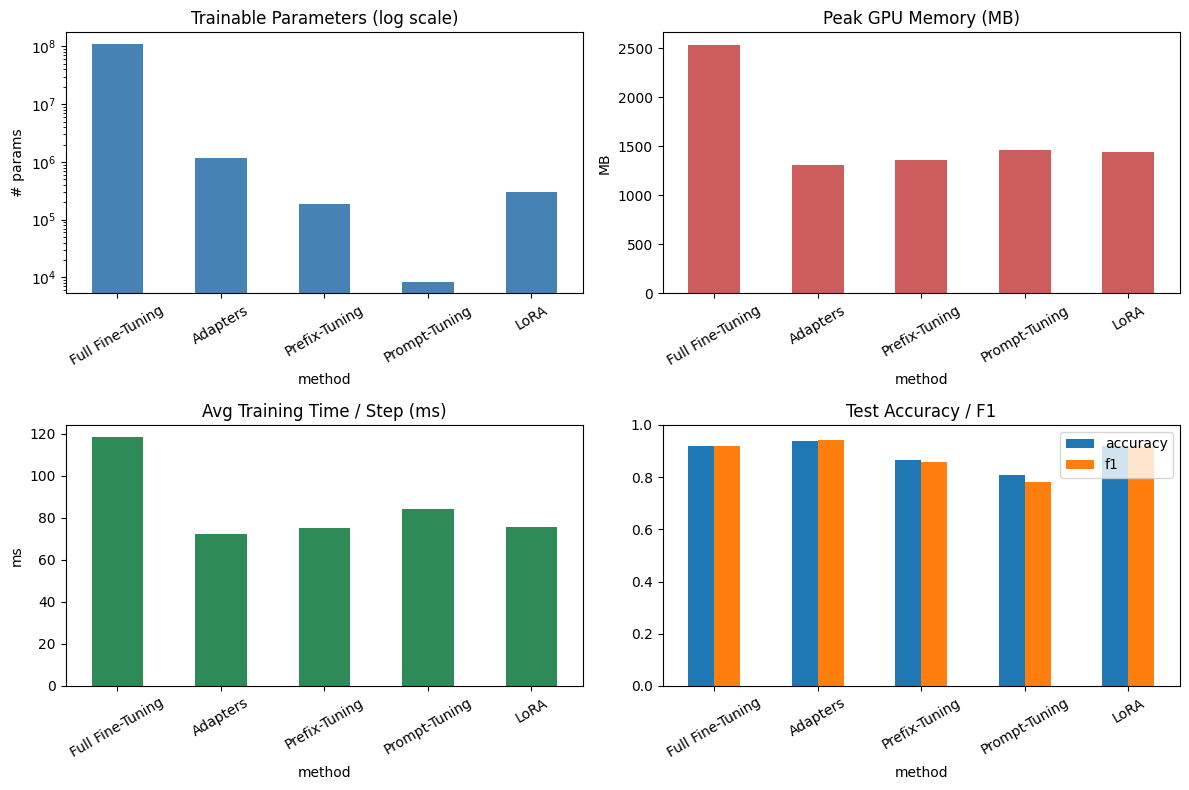

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

results_df["trainable_params"].plot(kind="bar", ax=axes[0, 0], color="steelblue", logy=True)
axes[0, 0].set_title("Trainable Parameters (log scale)")
axes[0, 0].set_ylabel("# params")

results_df["peak_mem_mb"].plot(kind="bar", ax=axes[0, 1], color="indianred")
axes[0, 1].set_title("Peak GPU Memory (MB)")
axes[0, 1].set_ylabel("MB")

results_df["avg_step_ms"].plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Avg Training Time / Step (ms)")
axes[1, 0].set_ylabel("ms")

results_df[["accuracy", "f1"]].plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Test Accuracy / F1")
axes[1, 1].set_ylim(0, 1)

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Takeaways

- **Efficiency**: Full fine-tuning trains 100% of BERT's parameters; every PEFT method here trains well under 5%. Adapters and prefix-tuning add a modest number of new parameters per layer; prompt-tuning is by far the cheapest (only `n_tokens x hidden_size` parameters total); LoRA sits in between while adding no inference-time latency (unlike adapters/prefix-tuning) since $BA$ can be merged into $W_0$.
- **Memory/speed**: Freezing most of BERT means most activations still need to be stored for backprop through frozen layers, so peak memory and step time for the PEFT methods are closer to full fine-tuning than the trainable-parameter counts alone would suggest — the biggest efficiency win from PEFT is in optimizer state and per-task checkpoint size, not necessarily raw training throughput on a single GPU.
- **Performance**: On this small (1,000-example) toxicity dataset, all methods should land in a broadly similar accuracy/F1 range after a few epochs, with full fine-tuning typically slightly ahead and LoRA/adapters usually closest behind it; prompt-tuning, having the fewest parameters, is the most sensitive to prompt length and learning rate.

Re-run the cells above (or tweak `bottleneck`, `prefix_len`, `n_tokens`, `r`, epochs, or learning rates) to see how these trade-offs shift.